In [1]:
# Inicializa as bibliotecas necessárias
import re
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import joblib

# Define os caminhos dos diretórios
PATH_EXP_DIR = Path.cwd().parent
PATH_DIR = Path.cwd().parent / "notebook" # diretório atual
PATH_OUT = PATH_DIR / 'results' # diretório para salvar os resultados
PATH_PLOT = PATH_OUT / 'plots' # diretório para salvar as plotagens
PATH_MODEL = PATH_OUT / 'models' # diretório para salvar o modelo treinado
PATH_METRIC = PATH_OUT / 'metrics' # diretório para salvar as plotagens
print(PATH_DIR)
print(PATH_PLOT)
print(PATH_MODEL)
print(PATH_METRIC)

# Cria as pastas caso não existam
for p in [PATH_PLOT, PATH_MODEL, PATH_METRIC]:
    p.mkdir(parents=True, exist_ok=True)

/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/experiments/bfs_2d_pinn_corrector/notebook
/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/experiments/bfs_2d_pinn_corrector/notebook/results/plots
/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/experiments/bfs_2d_pinn_corrector/notebook/results/models
/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/experiments/bfs_2d_pinn_corrector/notebook/results/metrics


In [2]:
df = pd.read_csv(PATH_EXP_DIR / "results/comparisons/experiments_full.csv")
df

,run_id,experiment_name,experiment_config_name,experiment_type,model_type,seed,start_time,end_time,log_path,wall_time_sec,...,pinn_momentum_val_score_min,pinn_momentum_val_data_initial,pinn_momentum_val_data_final,pinn_momentum_val_data_min,pinn_momentum_val_cont_initial,pinn_momentum_val_cont_final,pinn_momentum_val_cont_min,pinn_momentum_best_val_initial,pinn_momentum_best_val_final,pinn_momentum_best_val_min
0,mlp_base_k_epsilon_20260727_211435,mlp_base,base,k_epsilon,mlp,42,2026-07-27 21:14:36.146810,2026-07-27 21:19:13.974436,logs/mlp/mlp_base_20260727_211435/mlp_base_k_e...,277.827632,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mlp_base_k_epsilon_20260727_213239,mlp_base,base,k_epsilon,mlp,42,2026-07-27 21:32:39.604095,2026-07-27 21:37:12.697078,logs/mlp/mlp_base_20260727_213239/mlp_base_k_e...,273.092971,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,mlp_base_k_epsilon_20260728_022858,mlp_base,base,k_epsilon,mlp,42,2026-07-28 02:28:58.165951,2026-07-28 02:33:41.358933,logs/mlp/mlp_base_20260728_022858/mlp_base_k_e...,283.192979,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,mlp_base_k_epsilon_20260729_192246,mlp_base,base,k_epsilon,mlp,42,2026-07-29 19:22:46.904479,2026-07-29 19:27:22.293471,logs/mlp/mlp_base_20260729_192246/mlp_base_k_e...,275.388990,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mlp_base_k_epsilon_20260826_003112,mlp_base,base,k_epsilon,mlp,42,2026-08-26 00:31:13.039805,2026-08-26 00:35:53.084928,logs/mlp/mlp_base_20260826_003112/mlp_base_k_e...,280.045118,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,mlp_base_k_epsilon_20260826_185718,mlp_base,base,k_epsilon,mlp,42,2026-08-26 18:57:19.299332,2026-08-26 19:02:01.768626,logs/mlp/mlp_base_20260826_185718/mlp_base_k_e...,282.469291,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,mlp_base_k_epsilon_20260827_014547,mlp_base,base,k_epsilon,mlp,42,2026-08-27 01:45:47.614088,2026-08-27 01:50:23.122051,logs/mlp/mlp_base_20260827_014547/mlp_base_k_e...,275.507951,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,mlp_base_k_epsilon_20260902_012746,mlp_base,base,k_epsilon,mlp,42,2026-09-02 01:27:46.849465,2026-09-02 01:32:54.407849,logs/mlp/mlp_base_20260902_012746/mlp_base_k_e...,307.558381,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,mlp_base_k_epsilon_20260902_144142,mlp_base,base,k_epsilon,mlp,42,2026-09-02 14:41:42.515890,2026-09-02 14:46:04.604631,logs/mlp/mlp_base_20260902_144142/mlp_base_k_e...,262.088741,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,mlp_base_k_epsilon_20260728_172444,mlp_base,base,k_epsilon,mlp,123,2026-07-28 17:24:45.016886,2026-07-28 17:32:37.761903,logs/mlp/mlp_base_20260728_172444/mlp_base_k_e...,472.745018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df['start_time'].dtype

dtype('O')

In [27]:
df["start_time"] = pd.to_datetime(df["start_time"])

In [29]:
df.loc[df['experiment_name'].isin(['mlp_base', 'pinn_cont_base']) & (df['start_time'] >= pd.to_datetime('2026-07-28'))]

,run_id,experiment_name,experiment_config_name,experiment_type,model_type,seed,start_time,end_time,log_path,wall_time_sec,...,pinn_momentum_val_score_min,pinn_momentum_val_data_initial,pinn_momentum_val_data_final,pinn_momentum_val_data_min,pinn_momentum_val_cont_initial,pinn_momentum_val_cont_final,pinn_momentum_val_cont_min,pinn_momentum_best_val_initial,pinn_momentum_best_val_final,pinn_momentum_best_val_min
2,mlp_base_k_epsilon_20260728_022858,mlp_base,base,k_epsilon,mlp,42,2026-07-28 02:28:58.165951,2026-07-28 02:33:41.358933,logs/mlp/mlp_base_20260728_022858/mlp_base_k_e...,283.192979,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,mlp_base_k_epsilon_20260729_192246,mlp_base,base,k_epsilon,mlp,42,2026-07-29 19:22:46.904479,2026-07-29 19:27:22.293471,logs/mlp/mlp_base_20260729_192246/mlp_base_k_e...,275.388990,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mlp_base_k_epsilon_20260826_003112,mlp_base,base,k_epsilon,mlp,42,2026-08-26 00:31:13.039805,2026-08-26 00:35:53.084928,logs/mlp/mlp_base_20260826_003112/mlp_base_k_e...,280.045118,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,mlp_base_k_epsilon_20260826_185718,mlp_base,base,k_epsilon,mlp,42,2026-08-26 18:57:19.299332,2026-08-26 19:02:01.768626,logs/mlp/mlp_base_20260826_185718/mlp_base_k_e...,282.469291,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,mlp_base_k_epsilon_20260728_172444,mlp_base,base,k_epsilon,mlp,123,2026-07-28 17:24:45.016886,2026-07-28 17:32:37.761903,logs/mlp/mlp_base_20260728_172444/mlp_base_k_e...,472.745018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,mlp_base_k_epsilon_20260728_180551,mlp_base,base,k_epsilon,mlp,456,2026-07-28 18:05:51.383085,2026-07-28 18:11:15.350374,logs/mlp/mlp_base_20260728_180551/mlp_base_k_e...,323.967287,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,mlp_base_k_epsilon_20260729_184939,mlp_base,base,k_epsilon,mlp,456,2026-07-29 18:49:39.447288,2026-07-29 18:55:02.207038,logs/mlp/mlp_base_20260729_184939/mlp_base_k_e...,322.759747,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,pinn_cont_base_k_epsilon_20260728_020327,pinn_cont_base,cont_base,k_epsilon,pinn,42,2026-07-28 02:03:27.382543,2026-07-28 02:16:08.224895,logs/pinn/pinn_cont_base_20260728_020327/pinn_...,760.842349,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,pinn_cont_base_k_epsilon_20260728_041736,pinn_cont_base,cont_base,k_epsilon,pinn,42,2026-07-28 04:17:37.149406,2026-07-28 04:30:06.268434,logs/pinn/pinn_cont_base_20260728_041736/pinn_...,749.119020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,pinn_cont_base_k_epsilon_20260728_043931,pinn_cont_base,cont_base,k_epsilon,pinn,42,2026-07-28 04:39:31.922118,2026-07-28 04:52:05.780408,logs/pinn/pinn_cont_base_20260728_043931/pinn_...,753.858286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df2 = pd.read_csv(PATH_EXP_DIR / "results/comparisons/experiments_publication.csv")
df2

,model_type,experiment_name,experiment_type,width,depth,activation,features,w_cont,w_mom,mae_uv_corrected,rmse_uv_corrected,mae_p_corrected,rmse_p_corrected,mae_div_corrected,rmse_div_corrected,linf_div_corrected,wall_time_min
0,mlp,mlp_base,k_epsilon,64,4,tanh,"x, y, Ux, Uy, p, Re_norm",NaN,NaN,0.695273 ± 0.019092,1.278633 ± 0.049044,16.637347 ± 0.243393,26.304992 ± 0.113630,116.299141 ± 8.955687,434.043925 ± 48.865460,18195.995263 ± 1782.882978,5.169424 ± 1.067392
1,pinn,pinn_cont_base,k_epsilon,64,4,tanh,"x, y, Ux, Uy, p, Re_norm",0.000050,0.00001,0.754624,1.349210,17.581047,28.057041,2.878993,4.919715,276.806124,12.485317
2,pinn,pinn_cont_base,k_epsilon,64,4,tanh,"x, y, Ux, Uy, p, Re_norm",0.000075,0.00001,0.767176 ± 0.026906,1.390107 ± 0.024406,17.840823 ± 0.202532,29.725262 ± 1.115465,2.460958 ± 0.116424,4.442039 ± 0.112278,257.295601 ± 122.639765,13.400795 ± 1.239408
3,pinn,pinn_cont_base,k_epsilon,64,4,tanh,"x, y, Ux, Uy, p, Re_norm",0.000100,0.00001,0.835997 ± 0.000000,1.475412 ± 0.000000,18.835859 ± 0.000000,30.270622 ± 0.000000,2.343685 ± 0.000000,4.180474 ± 0.000000,321.861270 ± 0.000000,12.550995 ± 0.146784
4,pinn,pinn_cont_mom_base,k_epsilon,64,4,tanh,"x, y, Ux, Uy, p, Re, nut_log",0.000075,0.00005,0.877524,1.600874,24.220604,40.345585,2.680035,5.646775,235.165568,20.242668
5,pinn,pinn_mom_base,k_epsilon,64,4,tanh,"x, y, Ux, Uy, p, Re, nut_log",0.000075,0.00001,0.752155,1.333510,20.061764,32.410992,98.172162,310.123356,8973.723006,12.081335


In [6]:
df3 = pd.read_csv(PATH_EXP_DIR / "results/comparisons/experiments_main_comparison.csv")
df3

,run_id,model_type,experiment_name,experiment_type,seed,width,depth,activation,n_features,features,...,rmse_p_corrected,l2_rel_p_corrected,mae_div_corrected,rmse_div_corrected,linf_div_corrected,rmse_div_error_vs_fine,improvement_mae_uv_pct,improvement_mae_p_pct,improvement_div_rmse_vs_coarse_pct,improvement_div_rmse_vs_fine_pct
0,mlp_base_k_epsilon_20260727_211435,mlp,mlp_base,k_epsilon,42,64,4,tanh,6,"x, y, Ux, Uy, p, Re_norm",...,26.304447,0.065760,122.233450,465.662665,19221.392804,465.705482,88.299225,94.116831,-13688.511887,-8577.501907
1,mlp_base_k_epsilon_20260727_213239,mlp,mlp_base,k_epsilon,42,64,4,tanh,6,"x, y, Ux, Uy, p, Re_norm",...,26.304447,0.065760,122.233450,465.662665,19221.392804,465.705482,88.299225,94.116831,-13688.511887,-8577.501907
2,mlp_base_k_epsilon_20260728_022858,mlp,mlp_base,k_epsilon,42,64,4,tanh,6,"x, y, Ux, Uy, p, Re_norm",...,26.304447,0.065760,122.233450,465.662665,19221.392804,465.705482,88.299225,94.116831,-13688.511887,-8577.501907
3,mlp_base_k_epsilon_20260729_192246,mlp,mlp_base,k_epsilon,42,64,4,tanh,6,"x, y, Ux, Uy, p, Re_norm",...,26.304447,0.065760,122.233450,465.662665,19221.392804,465.705482,88.299225,94.116831,-13688.511887,-8577.501907
4,mlp_base_k_epsilon_20260826_003112,mlp,mlp_base,k_epsilon,42,64,4,tanh,6,"x, y, Ux, Uy, p, Re_norm",...,26.304447,0.065760,122.233450,465.662665,19221.392804,465.705482,88.299225,94.116831,-13688.511887,-8577.501907
5,mlp_base_k_epsilon_20260826_185718,mlp,mlp_base,k_epsilon,42,64,4,tanh,6,"x, y, Ux, Uy, p, Re_norm",...,26.304447,0.065760,122.233450,465.662665,19221.392804,465.705482,88.299225,94.116831,-13688.511887,-8577.501907
6,mlp_base_k_epsilon_20260728_172444,mlp,mlp_base,k_epsilon,123,64,4,tanh,6,"x, y, Ux, Uy, p, Re_norm",...,26.568491,0.066560,106.703001,343.637088,14062.981558,343.675165,88.228739,94.198298,-10075.271556,-6303.587207
7,mlp_base_k_epsilon_20260728_180551,mlp,mlp_base,k_epsilon,456,64,4,tanh,6,"x, y, Ux, Uy, p, Re_norm",...,26.174875,0.066070,103.294283,384.391124,17186.309493,384.461222,88.886476,94.279663,-11282.019622,-7063.028018
8,mlp_base_k_epsilon_20260729_184939,mlp,mlp_base,k_epsilon,456,64,4,tanh,6,"x, y, Ux, Uy, p, Re_norm",...,26.174875,0.066070,103.294283,384.391124,17186.309493,384.461222,88.886476,94.279663,-11282.019622,-7063.028018
9,pinn_cont_base_k_epsilon_20260725_205129,pinn,pinn_cont_base,k_epsilon,42,64,4,tanh,6,"x, y, Ux, Uy, p, Re_norm",...,30.270622,0.075675,2.343685,4.180474,321.861270,6.691542,86.105631,93.400094,-23.785997,22.097958


In [22]:
df_loss = pd.read_csv(PATH_EXP_DIR / "logs/mlp/mlp_base_20260902_160054/mlp_loss_history_base_20260902_160054.csv")
df_loss.head()

,epoch,loss_total,loss_val,lr
0,1,0.831261,0.740119,0.001
1,2,0.702237,0.702649,0.001
2,3,0.663450,0.663742,0.001
3,4,0.626273,0.630325,0.001
4,5,0.595195,0.599693,0.001


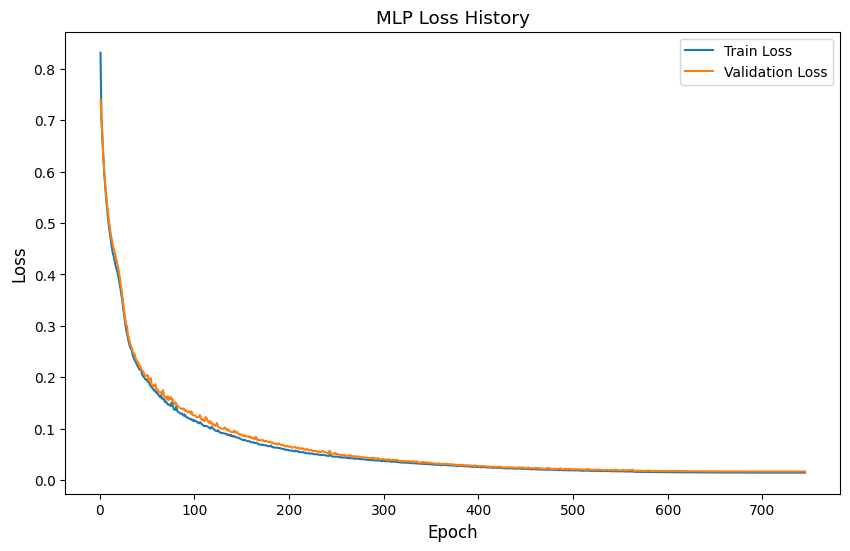

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(df_loss['epoch'], df_loss['loss_total'], label='Train Loss')
plt.plot(df_loss['epoch'], df_loss['loss_val'], label='Validation Loss')
plt.title('MLP Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [24]:
df_pinn_loss = pd.read_csv(PATH_EXP_DIR / "logs/pinn/pinn_cont_base_20260902_160507/pinn_loss_history_stage2_cont_base_20260902_160507.csv")
df_pinn_loss.head()

,epoch,loss_total,loss_data,loss_cont,loss_mom,val_score,val_data,val_cont,val_mom,norm_data,norm_cont,norm_mom,lr
0,1,8.057963,0.348210,102796.711857,NaN,27.730016,0.662556,40342.410088,NaN,39.524761,0.208945,NaN,0.001
1,2,2.552448,0.638859,25514.520450,NaN,26.798523,0.641046,18949.226099,NaN,38.241543,0.098143,NaN,0.001
2,3,1.483590,0.555829,12370.152976,NaN,22.603334,0.540858,11530.211779,NaN,32.264884,0.059718,NaN,0.001
3,4,1.094464,0.478526,8212.505917,NaN,20.191208,0.483215,8294.820876,NaN,28.826170,0.042961,NaN,0.001
4,5,0.897949,0.435334,6168.203527,NaN,18.698626,0.447528,6782.522016,NaN,26.697267,0.035129,NaN,0.001


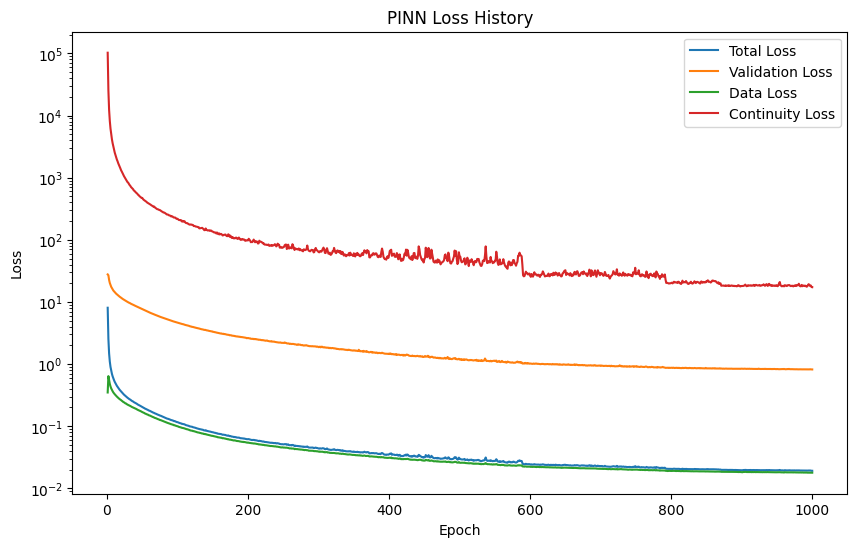

In [8]:
## PINN Loss History
plt.figure(figsize=(10, 6))
plt.plot(df_pinn_loss['epoch'], df_pinn_loss['loss_total'], label='Total Loss')
plt.plot(df_pinn_loss['epoch'], df_pinn_loss['val_score'], label='Validation Loss')
plt.plot(df_pinn_loss['epoch'], df_pinn_loss['loss_data'], label='Data Loss')
plt.plot(df_pinn_loss['epoch'], df_pinn_loss['loss_cont'], label='Continuity Loss')
plt.title('PINN Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()

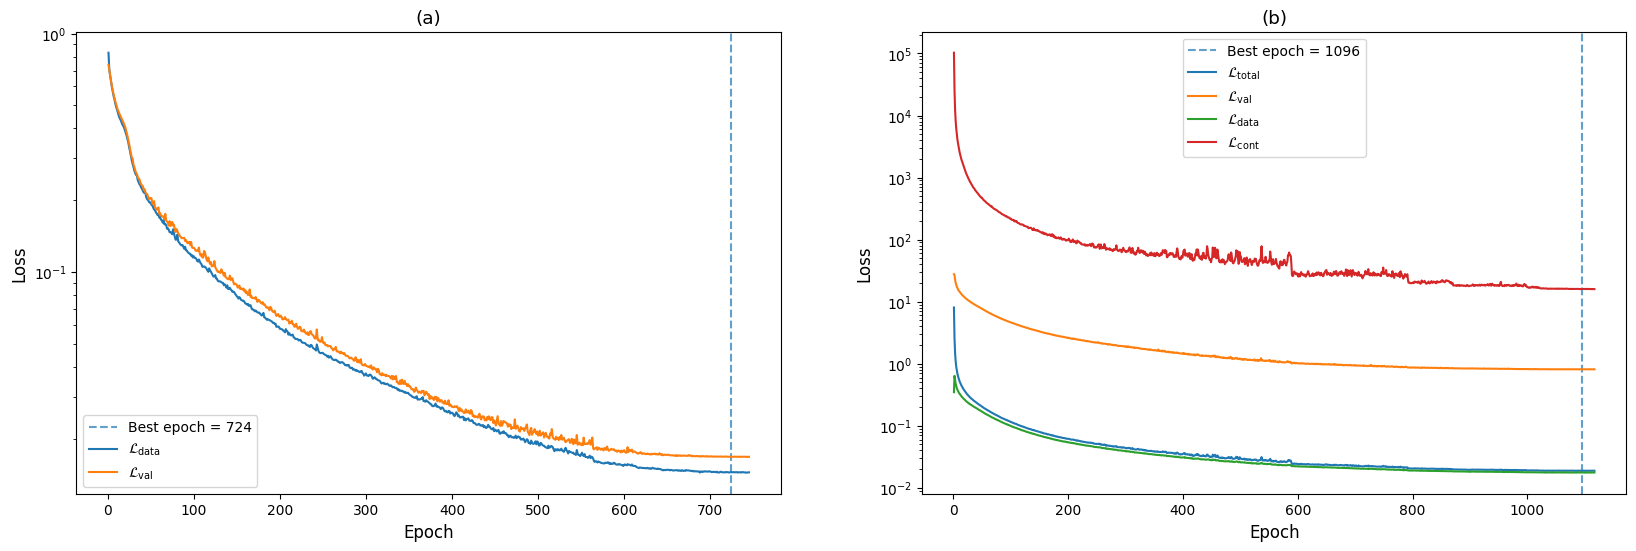

In [26]:
plt.figure(figsize=(20, 6))
ax = plt.subplot(1, 2, 1)
best_epoch = np.argmin(df_loss['loss_val'])
ax.axvline(best_epoch, linestyle="--", alpha=0.7,
           label=f"Best epoch = {best_epoch}")
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
plt.plot(df_loss['epoch'], df_loss['loss_total'], label=r'$\mathcal{{L}}_{{\mathrm{{data}}}}$')
plt.plot(df_loss['epoch'], df_loss['loss_val'], label=r'$\mathcal{{L}}_{{\mathrm{{val}}}}$')
plt.title('(a)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()

ax2 = plt.subplot(1, 2, 2)
best_epoch = np.argmin(df_pinn_loss['val_score'])
ax2.axvline(best_epoch, linestyle="--", alpha=0.7,
            label=f"Best epoch = {best_epoch}")
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
plt.plot(df_pinn_loss['epoch'], df_pinn_loss['loss_total'], label=r'$\mathcal{{L}}_{{\mathrm{{total}}}}$')
plt.plot(df_pinn_loss['epoch'], df_pinn_loss['val_score'], label=r'$\mathcal{{L}}_{{\mathrm{{val}}}}$')
plt.plot(df_pinn_loss['epoch'], df_pinn_loss['loss_data'], label=r'$\mathcal{{L}}_{{\mathrm{{data}}}}$')
plt.plot(df_pinn_loss['epoch'], df_pinn_loss['loss_cont'], label=r'$\mathcal{{L}}_{{\mathrm{{cont}}}}$')
plt.title('(b)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.savefig(PATH_PLOT / "training_history.png", dpi=300, bbox_inches="tight")